# Entropy loss dynamics

Focus: analyze actor entropy loss across steps, show stability, variance by seed, and how different algorithms behave over time.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlepad"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()


DATA_DIR = get_data_dir()

ent = pd.read_csv(DATA_DIR / 'entropyloss_wide.csv')
ent['seed'] = ent['seed'].astype(str)


DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




In [2]:

# Aggregate across seeds
ent_mean = ent.groupby(['Step', 'algorithm'], as_index=False)['actor/entropy_loss'].mean()

# Helper: rolling smooth for a single algorithm

def smooth_series(df, window=25):
    df = df.sort_values('Step')
    return df.assign(smooth=df['actor/entropy_loss'].rolling(window, min_periods=1).mean())


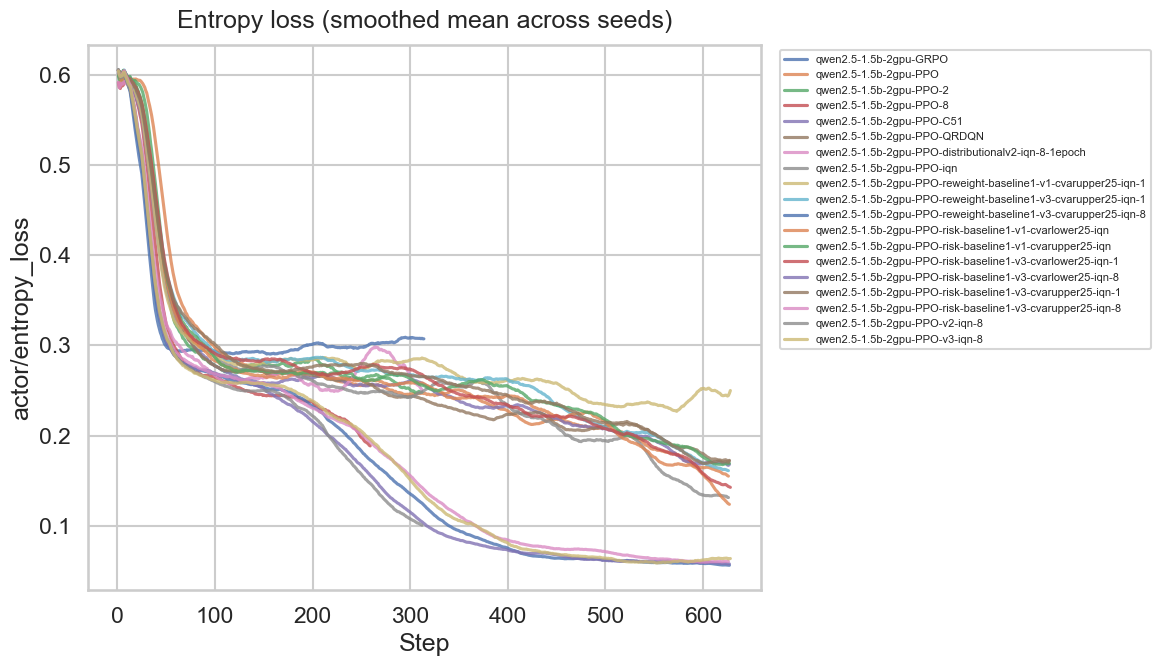

In [3]:

# Plot set A: overall smoothed mean curves
plt.figure(figsize=(12, 7))
for algo, sub in ent_mean.groupby('algorithm'):
    smooth = smooth_series(sub)
    plt.plot(smooth['Step'], smooth['smooth'], label=algo, alpha=0.8)
plt.title('Entropy loss (smoothed mean across seeds)')
plt.xlabel('Step')
plt.ylabel('actor/entropy_loss')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


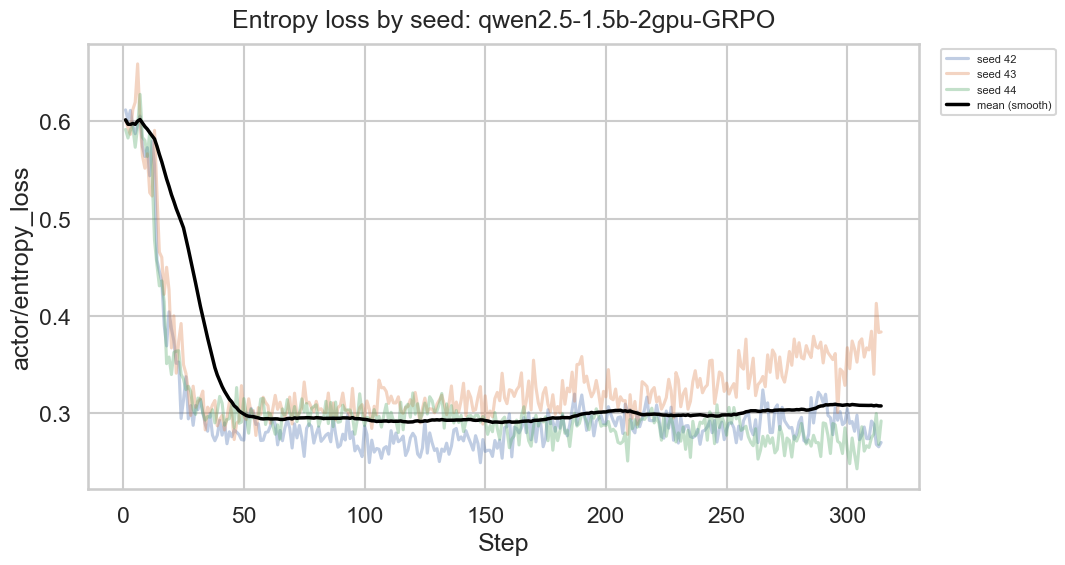

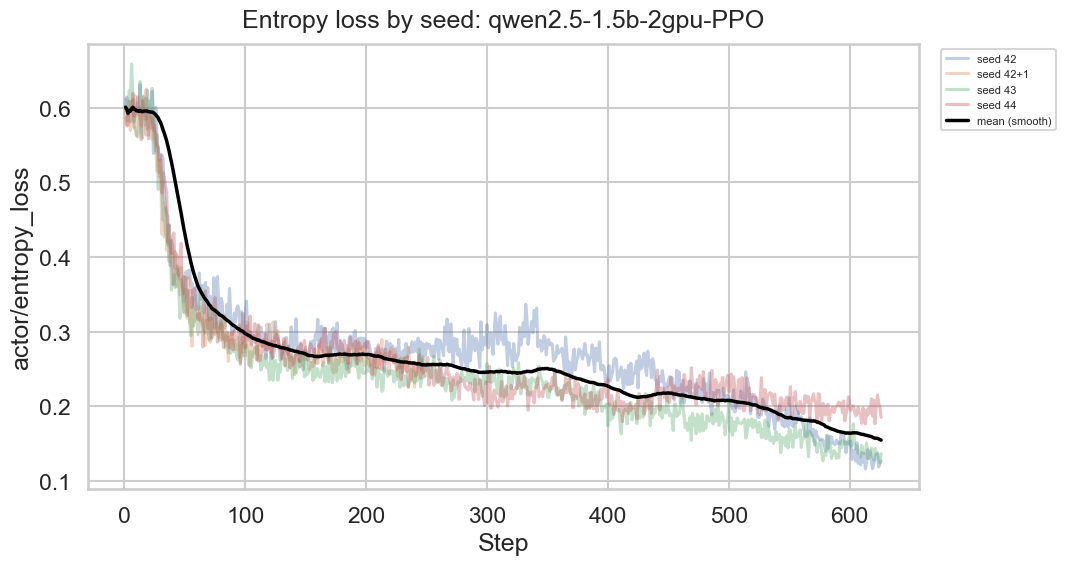

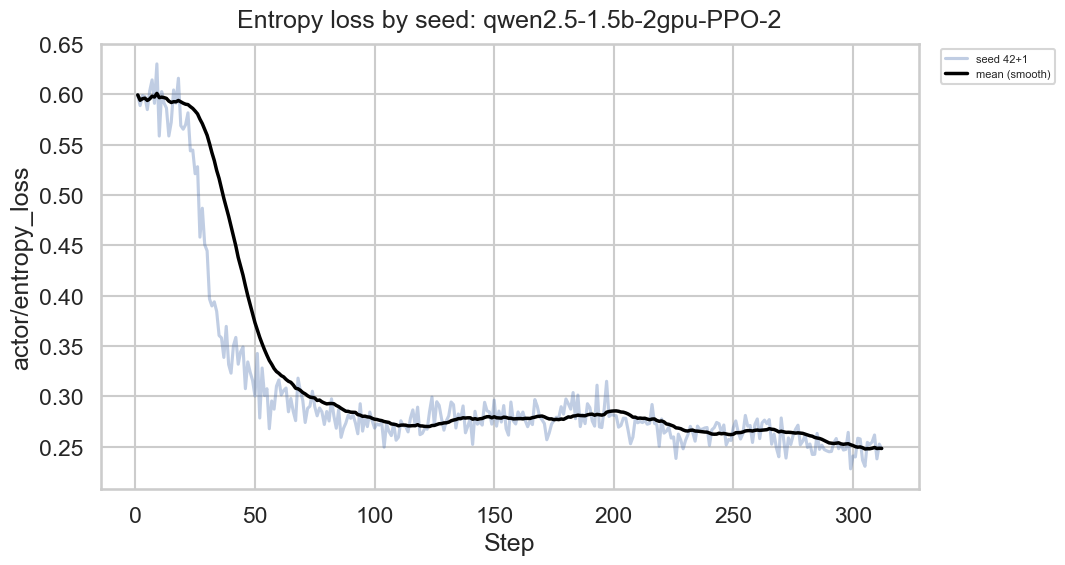

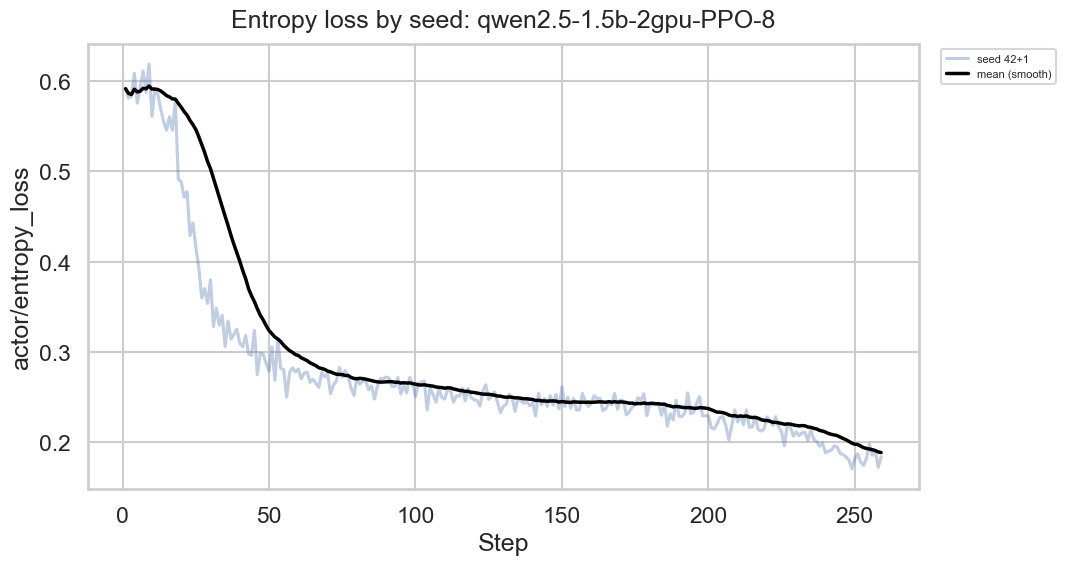

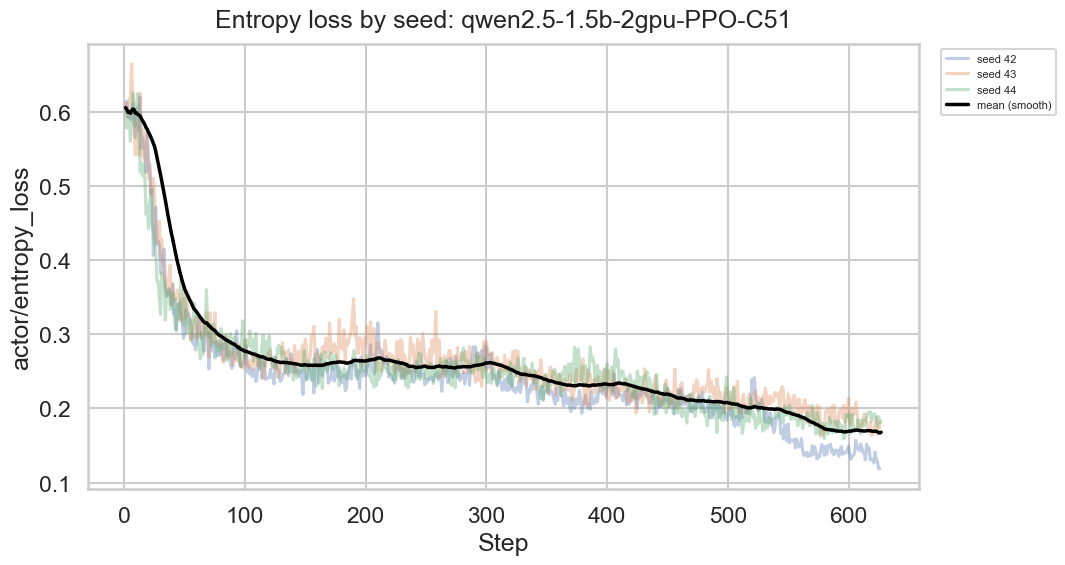

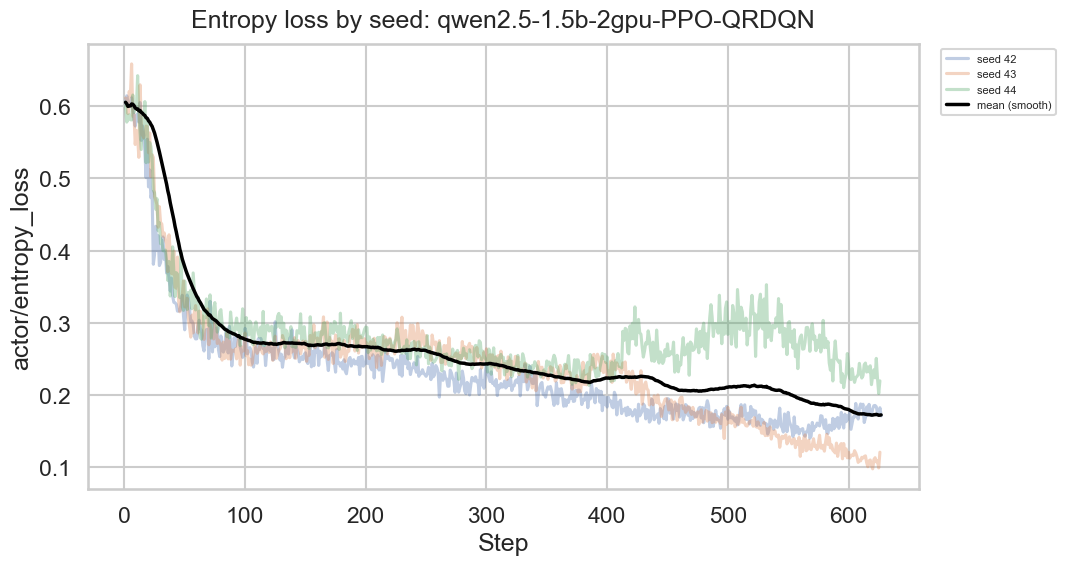

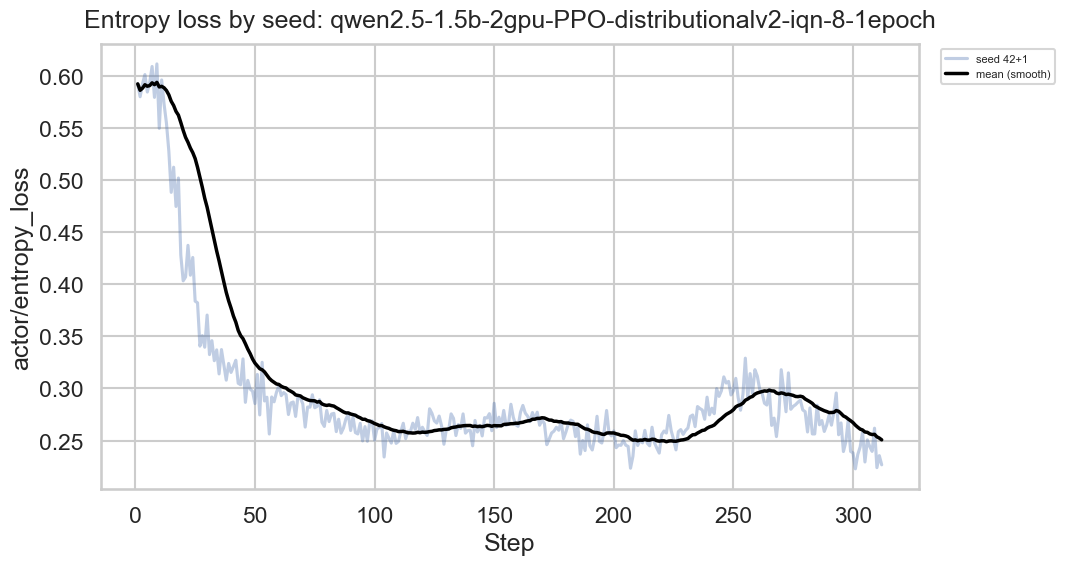

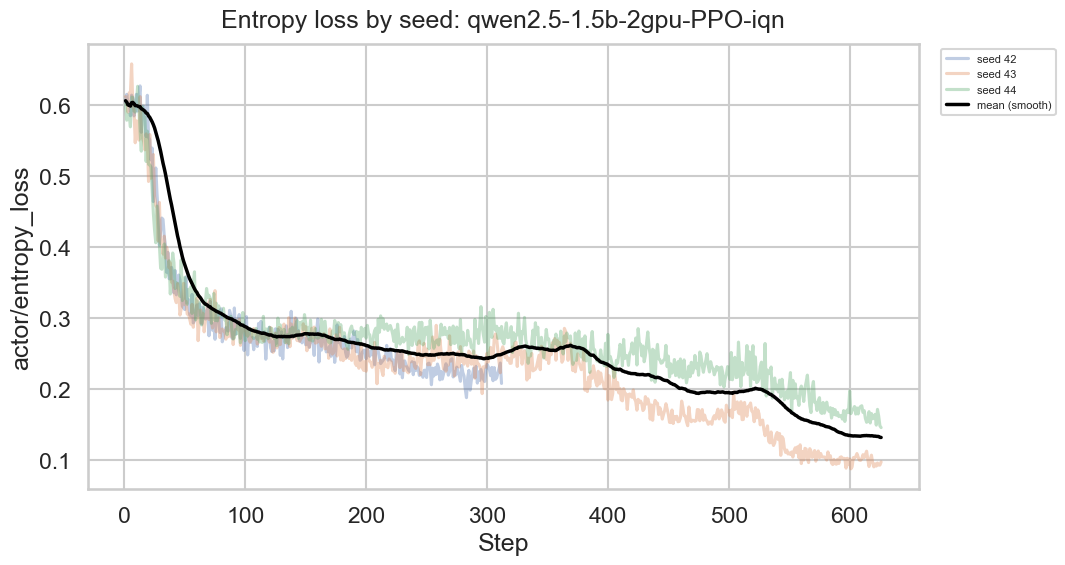

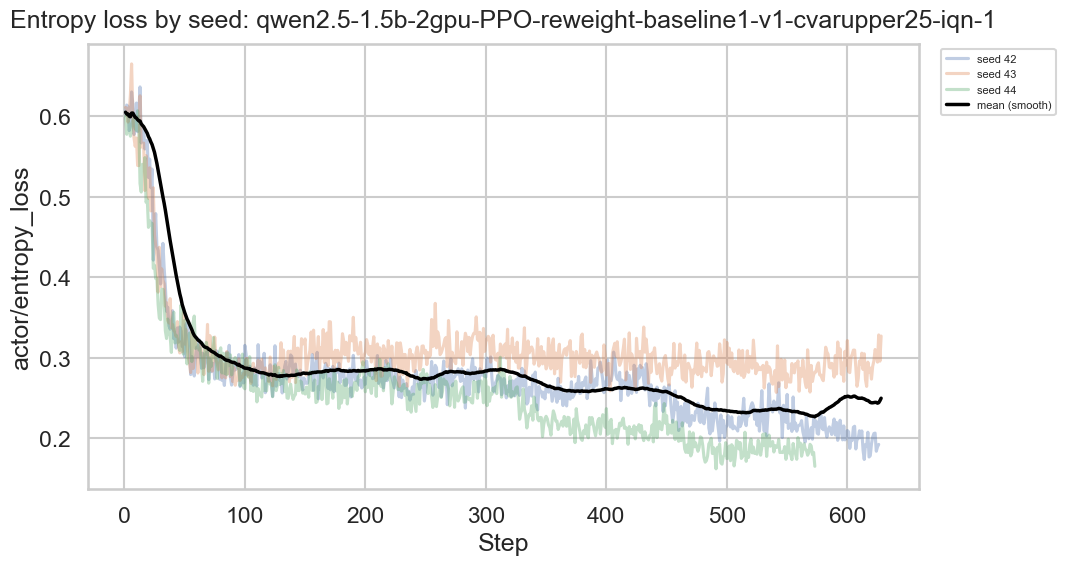

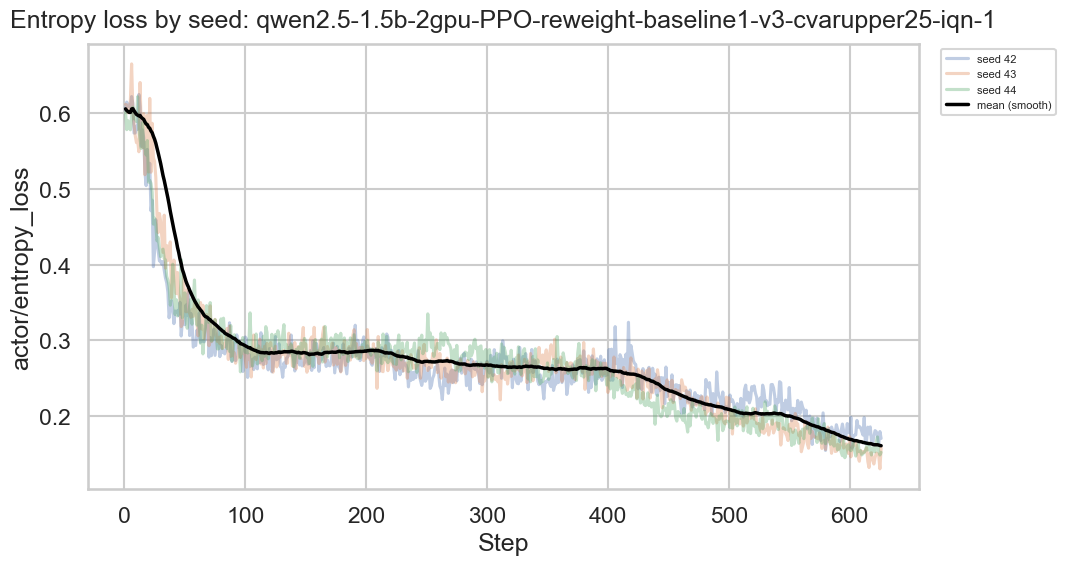

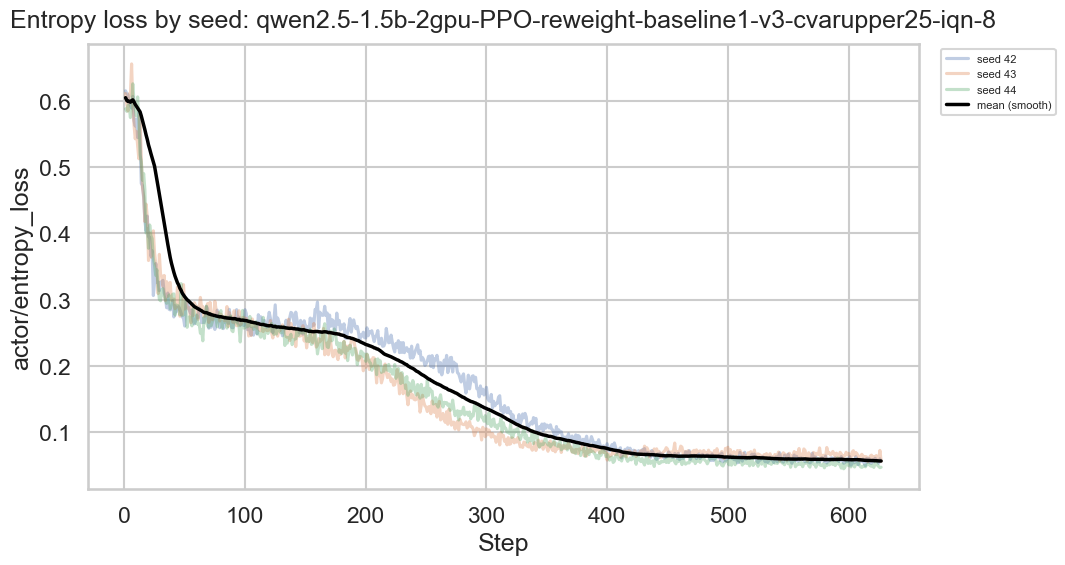

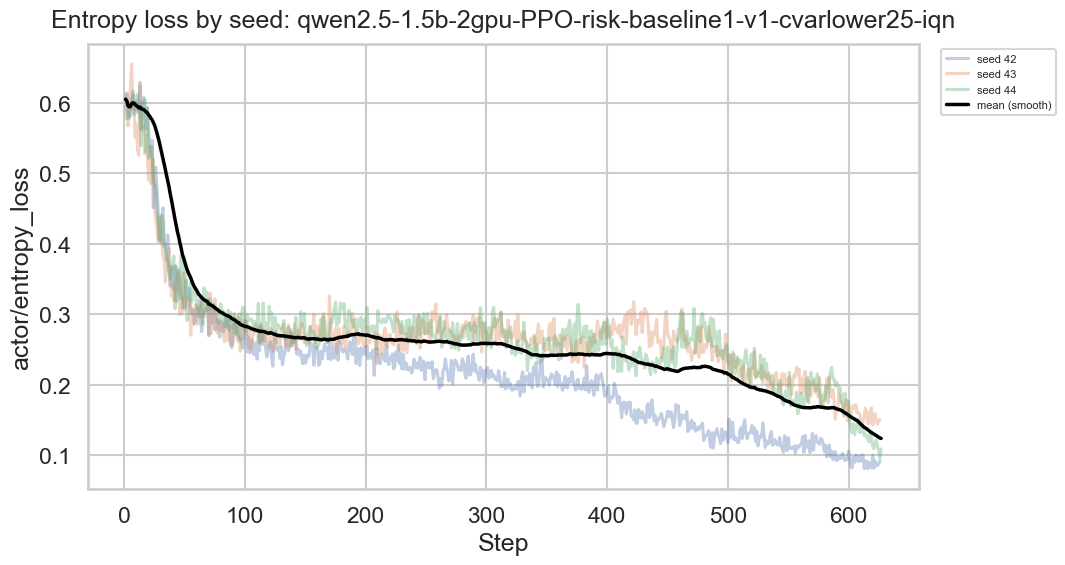

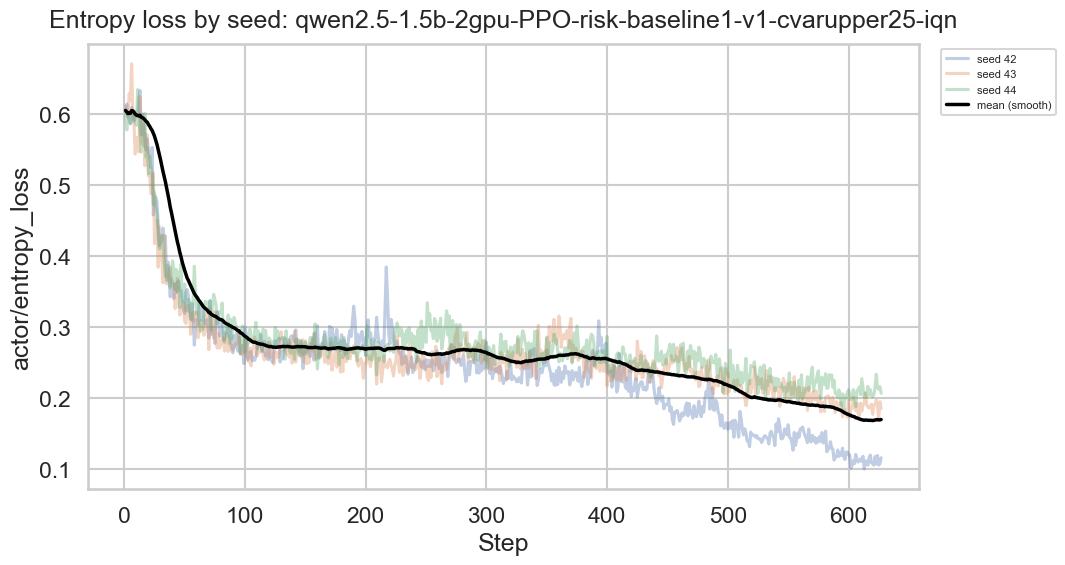

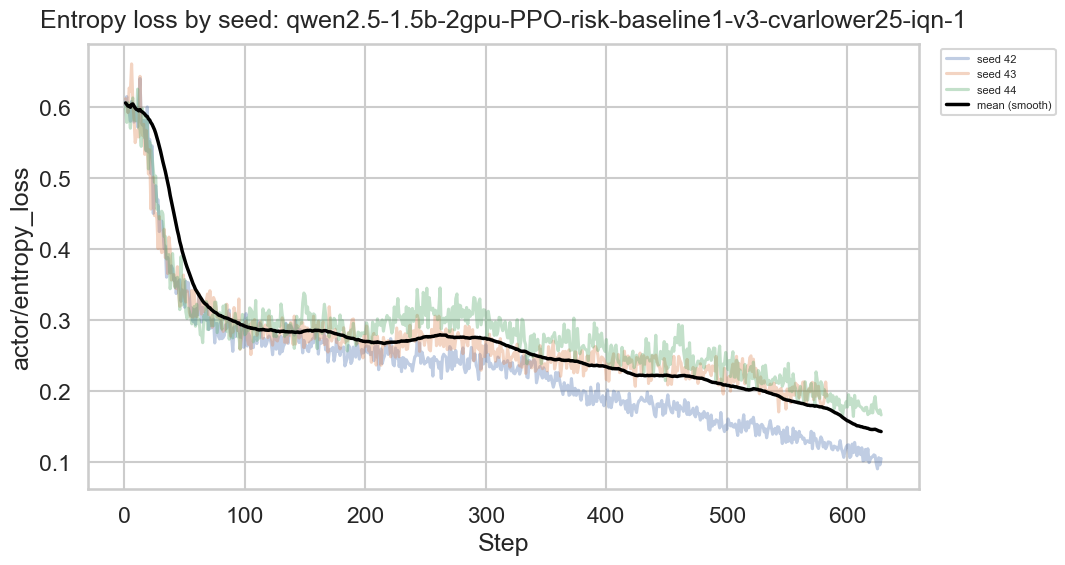

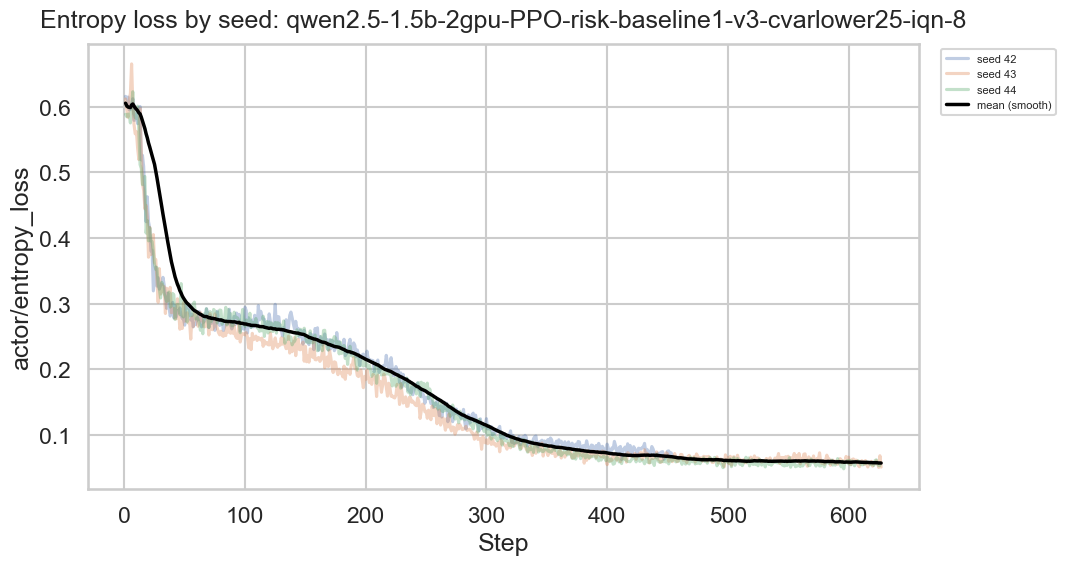

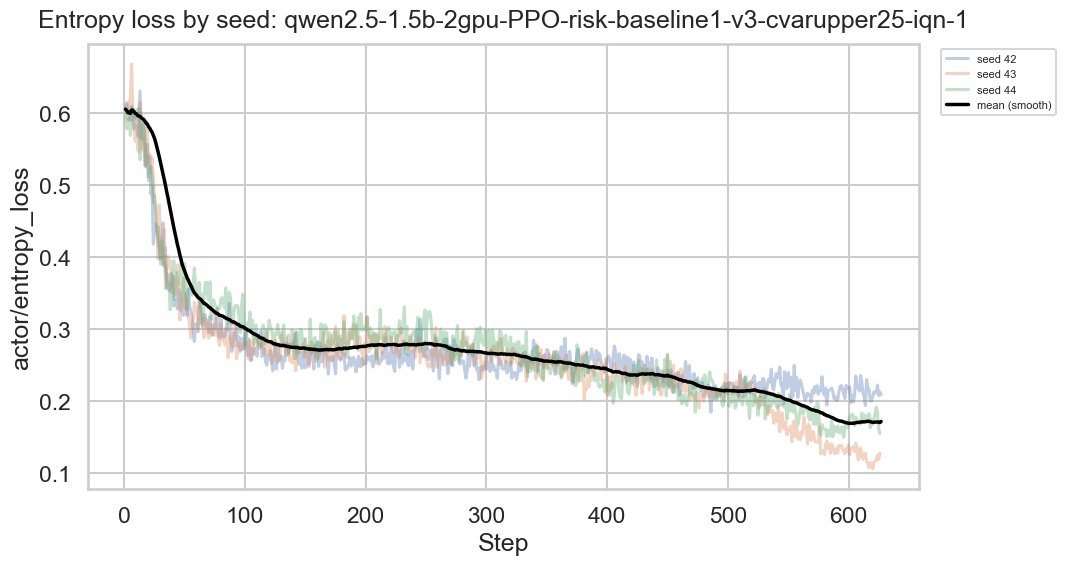

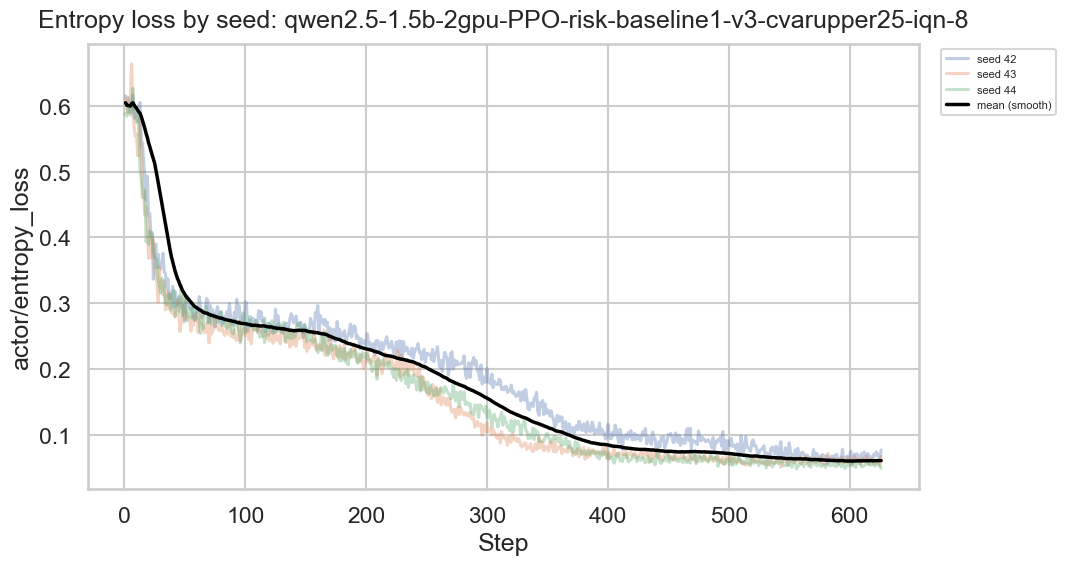

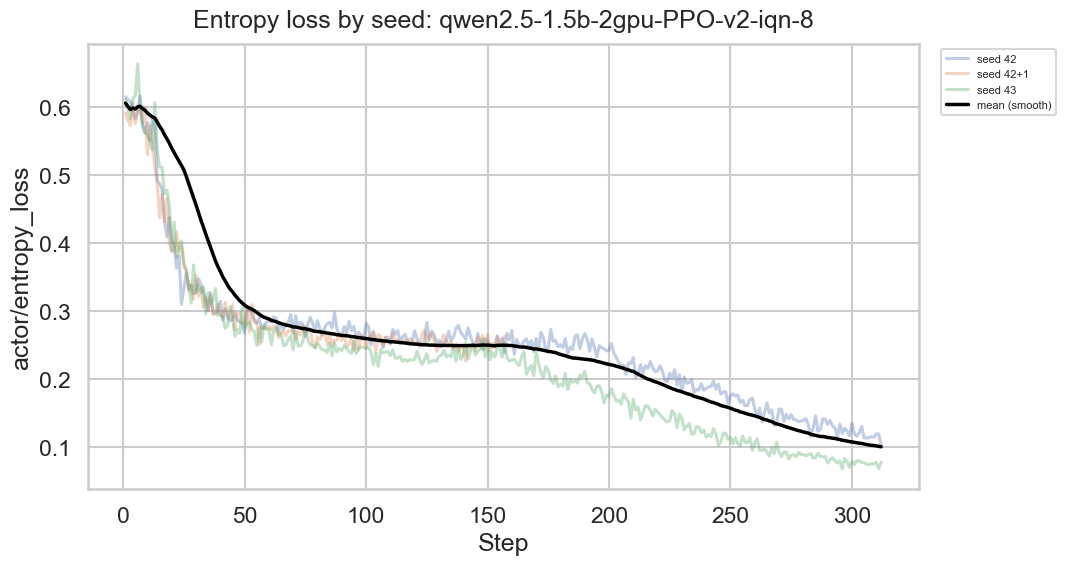

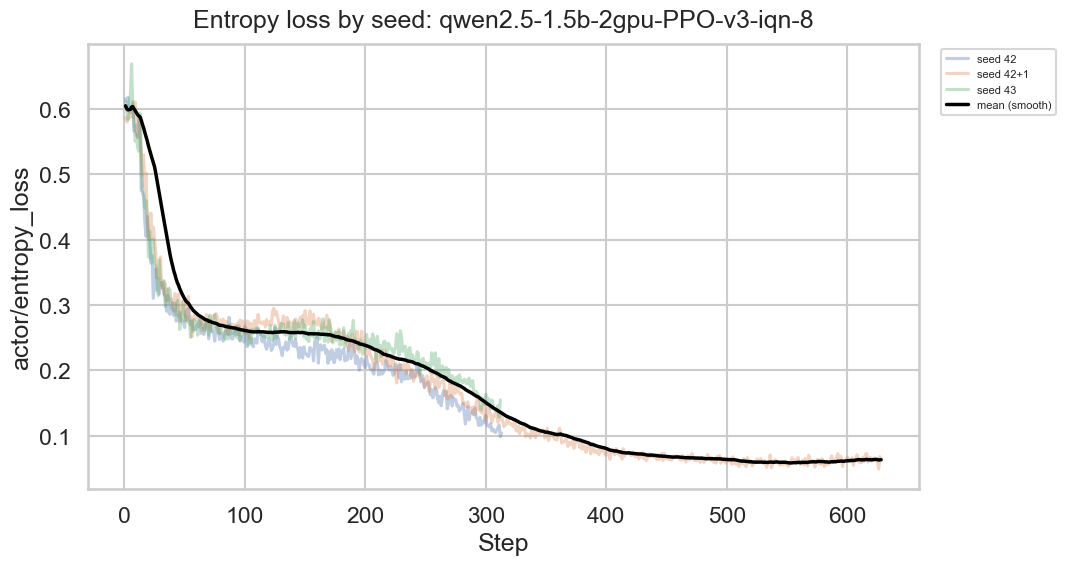

In [4]:

# Plot set B: per-algorithm, per-seed curves + smoothed mean
for algo, sub_algo in ent.groupby('algorithm'):
    plt.figure(figsize=(11, 6))
    for seed, sub_seed in sub_algo.groupby('seed'):
        sub_seed = sub_seed.sort_values('Step')
        plt.plot(sub_seed['Step'], sub_seed['actor/entropy_loss'], alpha=0.35, label=f'seed {seed}')
    mean_sub = ent_mean[ent_mean['algorithm'] == algo]
    smooth = smooth_series(mean_sub)
    plt.plot(smooth['Step'], smooth['smooth'], color='black', linewidth=2.5, label='mean (smooth)')
    plt.title(f'Entropy loss by seed: {algo}')
    plt.xlabel('Step')
    plt.ylabel('actor/entropy_loss')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close()


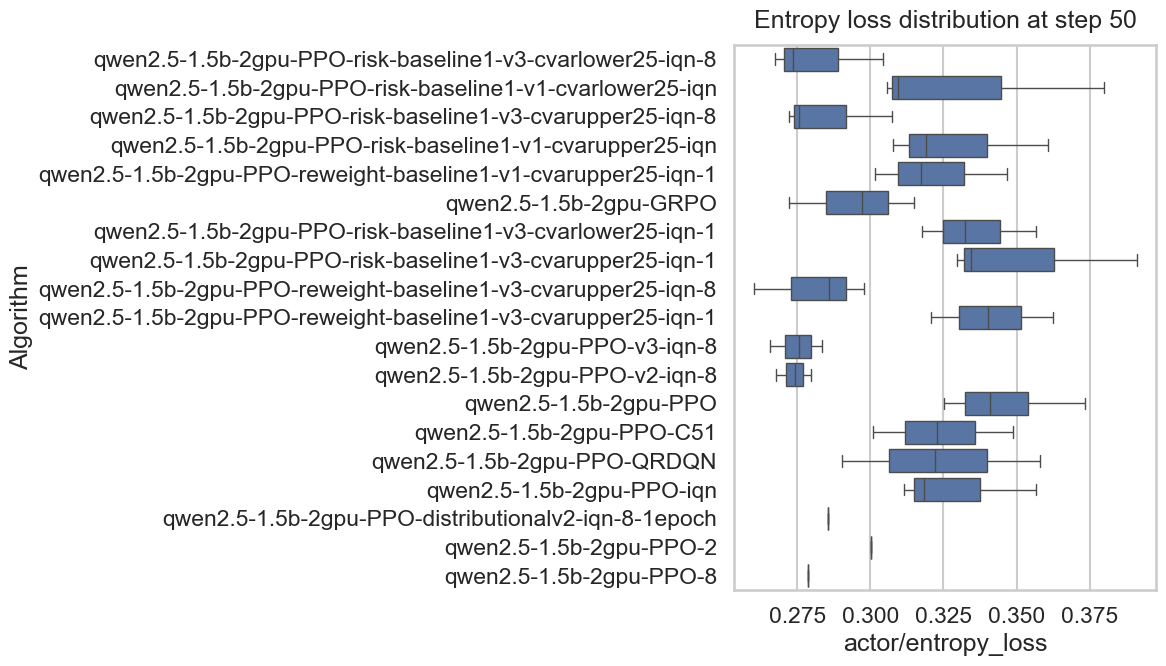

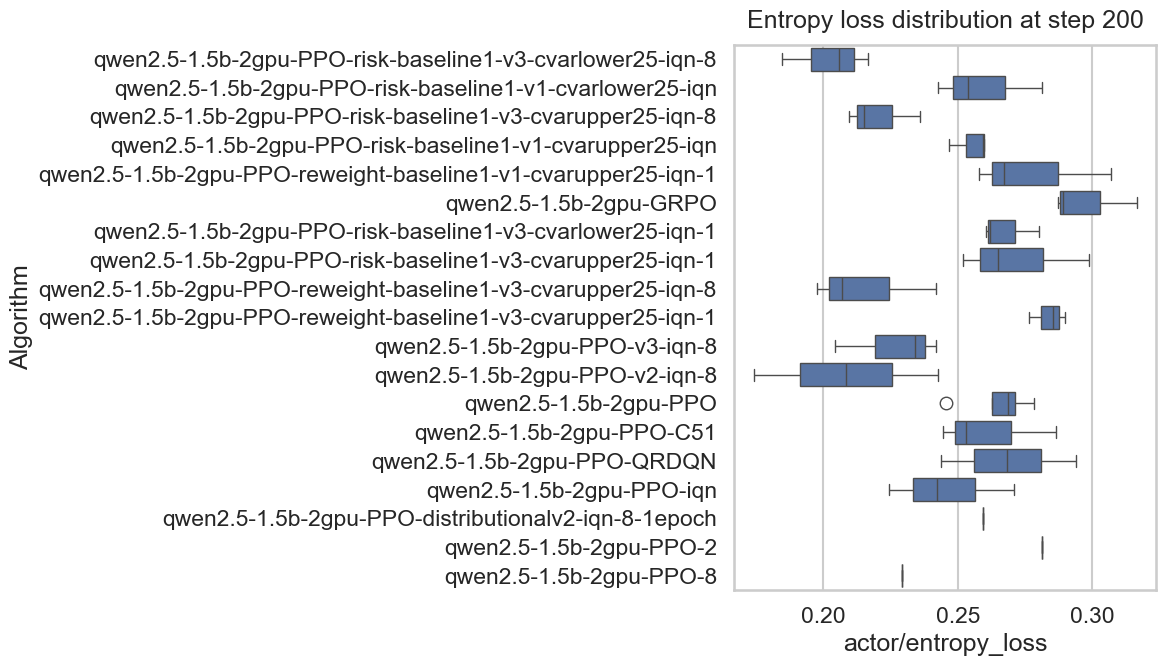

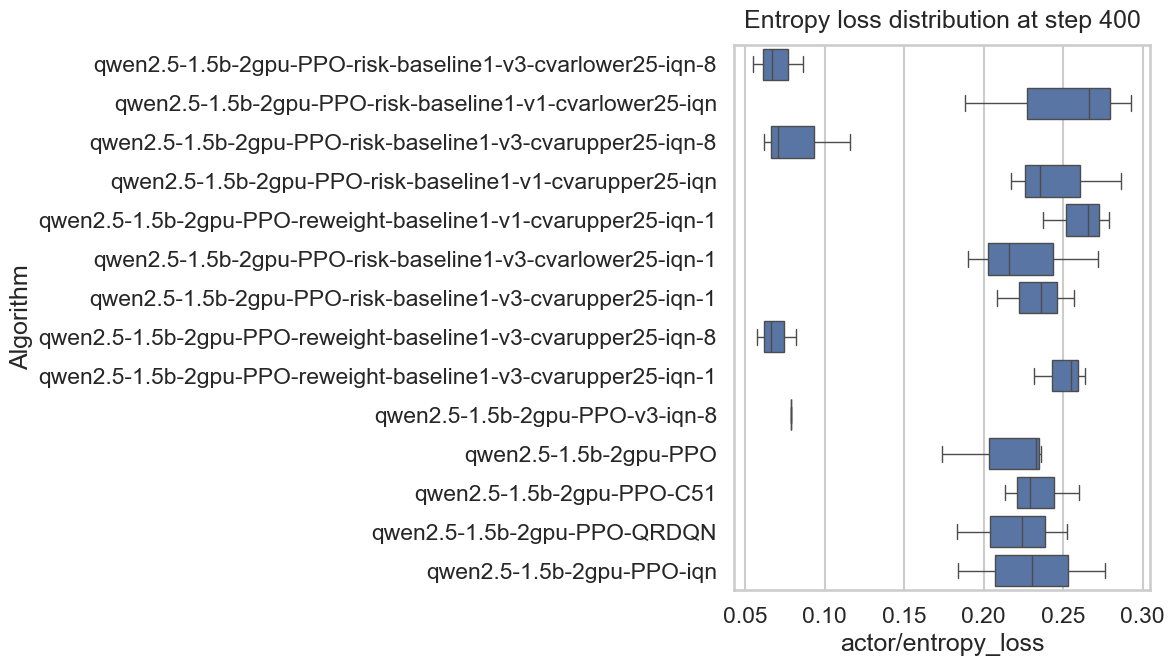

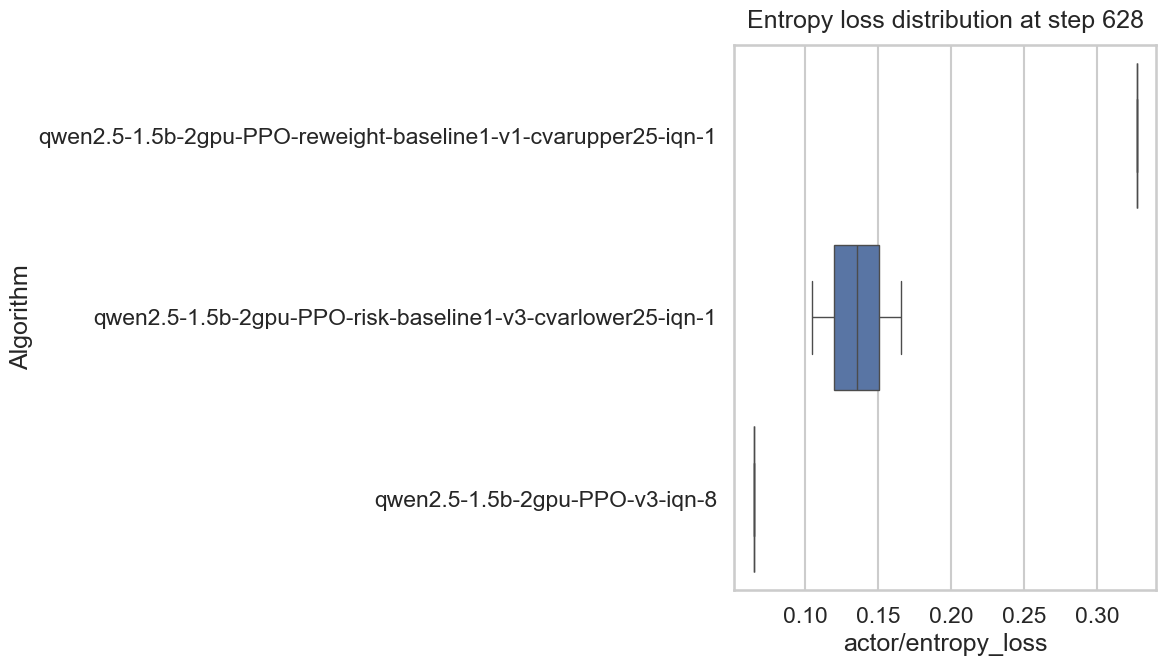

In [5]:

# Plot set C: distribution at selected steps
for step in [50, 200, 400, 628]:
    sub = ent[ent['Step'] == step]
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=sub, x='actor/entropy_loss', y='algorithm')
    plt.title(f'Entropy loss distribution at step {step}')
    plt.xlabel('actor/entropy_loss')
    plt.ylabel('Algorithm')
    plt.tight_layout()
    plt.show()
    plt.close()


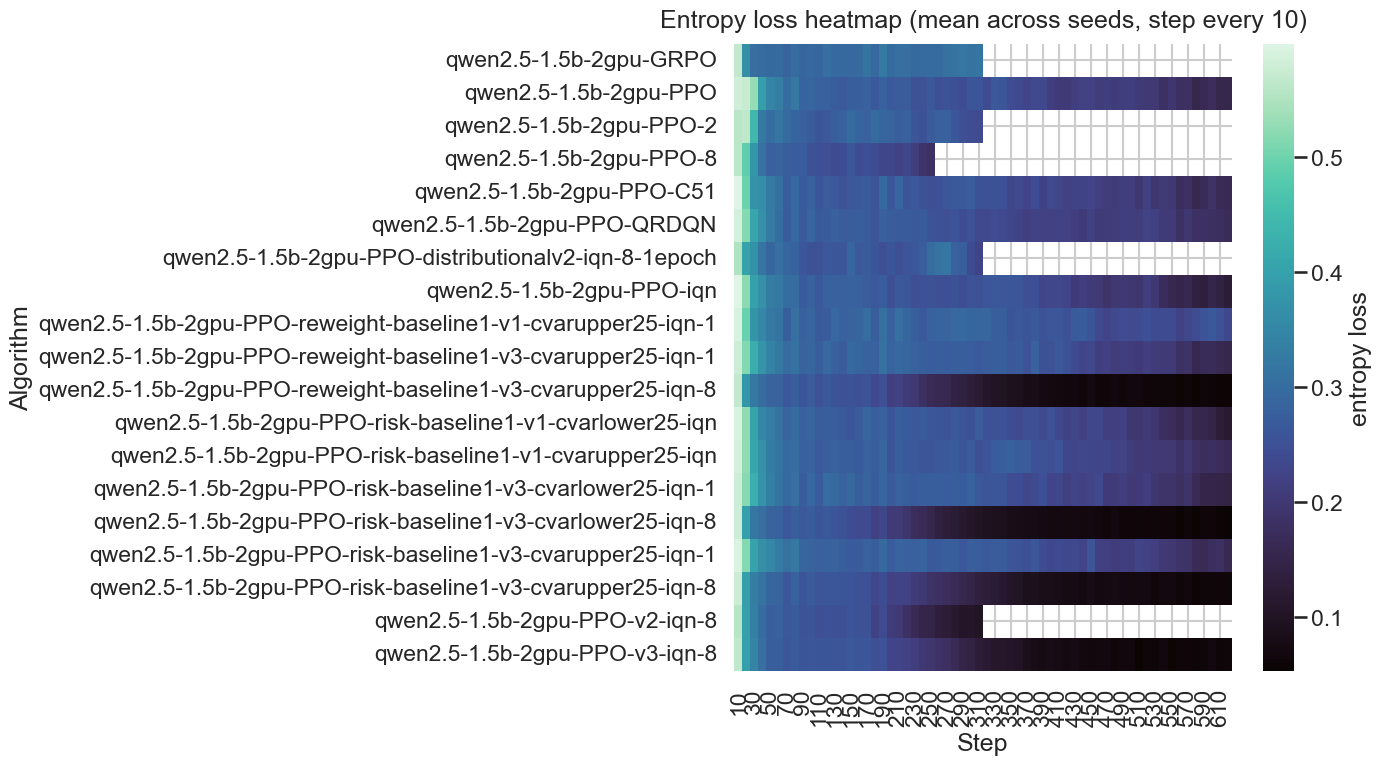

In [6]:

# Plot set D: heatmap of mean entropy loss (step downsampled)
sub = ent_mean[ent_mean['Step'] % 10 == 0]
pivot = sub.pivot(index='algorithm', columns='Step', values='actor/entropy_loss')
plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='mako', cbar_kws={'label': 'entropy loss'})
plt.title('Entropy loss heatmap (mean across seeds, step every 10)')
plt.xlabel('Step')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()
plt.close()
